In [1]:
import pandas as pd

# Load datasets
# Step 1: Load dataset
df = pd.read_csv('Energy-dataset/AEP_hourly.csv')

print("Files loaded successfully")

Files loaded successfully


In [2]:
# Step 2: Convert Datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [3]:
# Step 3: Set Datetime as index
df.set_index('Datetime', inplace=True)

In [4]:
# Sort by Datetime
df = df.sort_values('Datetime')


In [5]:
# Step 4: Sort data
df = df.sort_index()

In [6]:
df.shape

(121273, 1)

In [7]:
# Step 5: Check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 AEP_MW    0
dtype: int64


In [8]:
# Step 7: Feature Engineering
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['Year'] = df.index.year
df['DayOfWeek'] = df.index.dayofweek

In [9]:
df

,AEP_MW,Hour,Day,Month,Year,DayOfWeek
Datetime,,,,,,
2004-10-01 01:00:00,12379.0,1,1,10,2004,4
2004-10-01 02:00:00,11935.0,2,1,10,2004,4
2004-10-01 03:00:00,11692.0,3,1,10,2004,4
2004-10-01 04:00:00,11597.0,4,1,10,2004,4
2004-10-01 05:00:00,11681.0,5,1,10,2004,4
...,...,...,...,...,...,...
2018-08-02 20:00:00,17673.0,20,2,8,2018,3
2018-08-02 21:00:00,17303.0,21,2,8,2018,3
2018-08-02 22:00:00,17001.0,22,2,8,2018,3


In [10]:
# Display final data
print(df.head())

                      AEP_MW  Hour  Day  Month  Year  DayOfWeek
Datetime                                                       
2004-10-01 01:00:00  12379.0     1    1     10  2004          4
2004-10-01 02:00:00  11935.0     2    1     10  2004          4
2004-10-01 03:00:00  11692.0     3    1     10  2004          4
2004-10-01 04:00:00  11597.0     4    1     10  2004          4
2004-10-01 05:00:00  11681.0     5    1     10  2004          4


## M2: EDA (Exploratory Data Analysis)

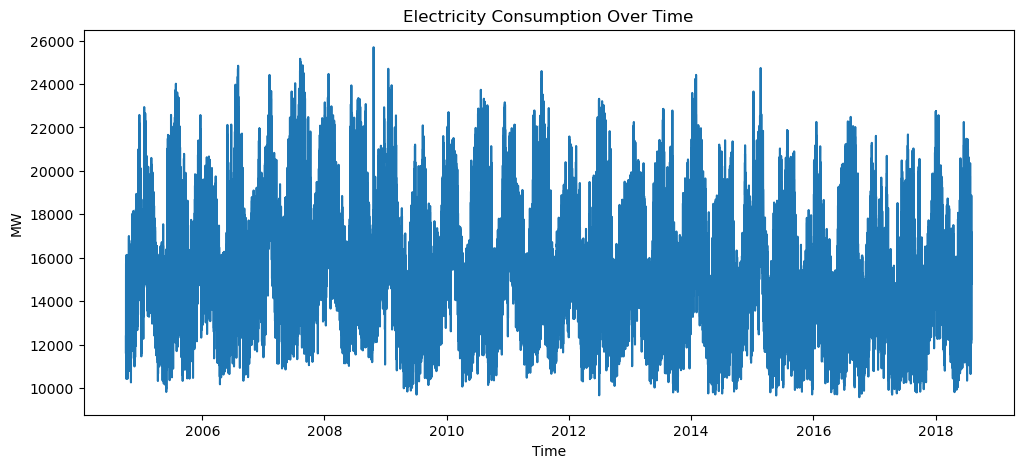

In [11]:
import matplotlib.pyplot as plt

# 1. Line Plot (Overall Trend)
plt.figure(figsize=(12,5))
plt.plot(df['AEP_MW'])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()

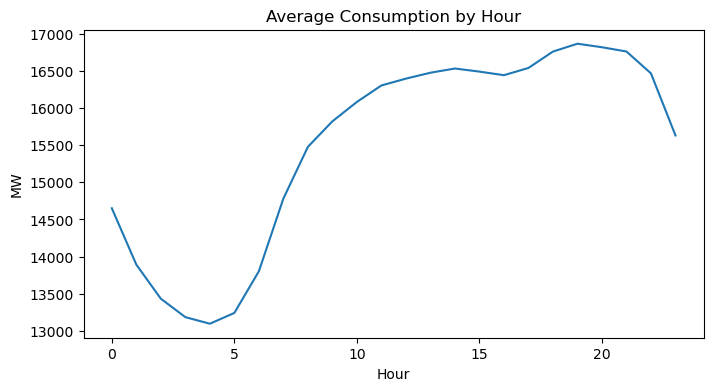

In [12]:
# 2. Daily Average Pattern
daily_avg = df.groupby('Hour')['AEP_MW'].mean()

plt.figure(figsize=(8,4))
plt.plot(daily_avg)
plt.title("Average Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("MW")
plt.show()

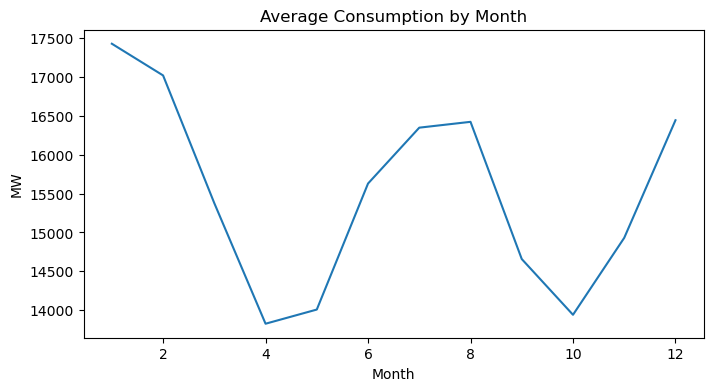

In [13]:
# 3. Monthly Pattern
monthly_avg = df.groupby('Month')['AEP_MW'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg)
plt.title("Average Consumption by Month")
plt.xlabel("Month")
plt.ylabel("MW")
plt.show()

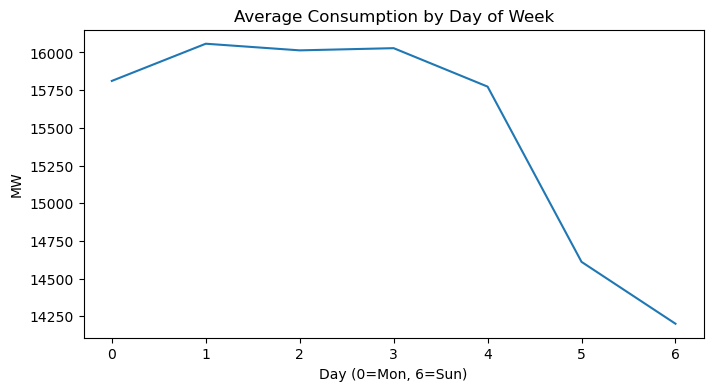

In [14]:
weekly_avg = df.groupby('DayOfWeek')['AEP_MW'].mean()

plt.figure(figsize=(8,4))
plt.plot(weekly_avg)
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day (0=Mon, 6=Sun)")
plt.ylabel("MW")
plt.show()

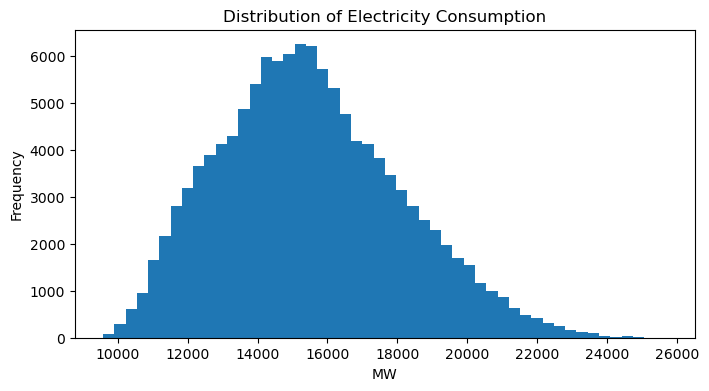

In [15]:
# 5. Distribution Plot
plt.figure(figsize=(8,4))
plt.hist(df['AEP_MW'], bins=50)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("MW")
plt.ylabel("Frequency")
plt.show()


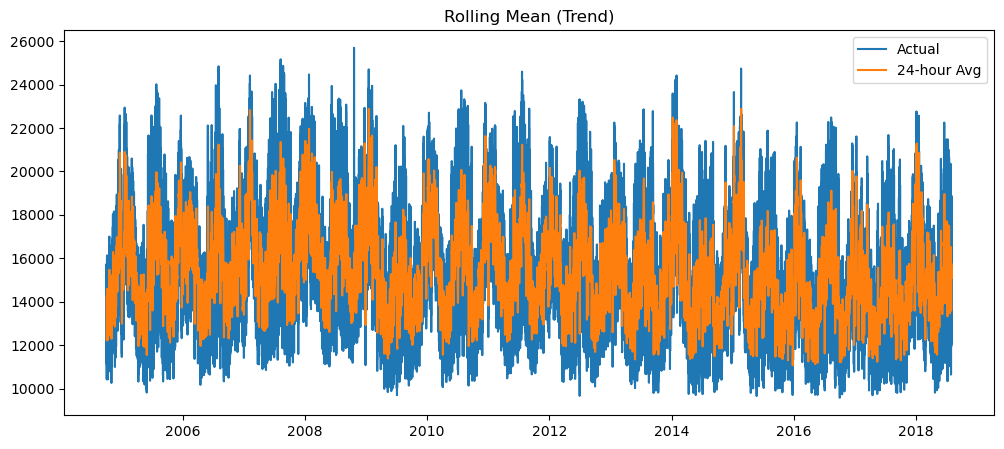

In [16]:
# 6. Rolling Mean (Trend Smoothing)
df['RollingMean'] = df['AEP_MW'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df['AEP_MW'], label='Actual')
plt.plot(df['RollingMean'], label='24-hour Avg')
plt.legend()
plt.title("Rolling Mean (Trend)")
plt.show()

## M3 – Probability Analysis

In [17]:
# Step 1: Define threshold (mean consumption)
threshold = df['AEP_MW'].mean()

# Step 2: Probability of High Consumption
high = df[df['AEP_MW'] > threshold]
p_high = len(high) / len(df)

print("P(High Consumption):", round(p_high, 3))


# Step 3: Probability of Low Consumption
low = df[df['AEP_MW'] <= threshold]
p_low = len(low) / len(df)

print("P(Low Consumption):", round(p_low, 3))


# Step 4: Conditional Probability
# Example: Probability of High Consumption during Peak Hours (say 17–21)

peak_hours = df[(df['Hour'] >= 17) & (df['Hour'] <= 21)]
high_peak = peak_hours[peak_hours['AEP_MW'] > threshold]

p_high_given_peak = len(high_peak) / len(peak_hours)

print("P(High | Peak Hours):", round(p_high_given_peak, 3))


# Step 5: Joint Probability
# Probability of High Consumption AND Peak Hour

joint = len(high_peak) / len(df)

print("P(High AND Peak):", round(joint, 3))

P(High Consumption): 0.469
P(Low Consumption): 0.531
P(High | Peak Hours): 0.656
P(High AND Peak): 0.137


In [18]:
import scipy.stats as stats

# Step 1: Create two groups (Weekday vs Weekend)
weekday = df[df['DayOfWeek'] < 5]['AEP_MW']   # Mon–Fri
weekend = df[df['DayOfWeek'] >= 5]['AEP_MW']  # Sat–Sun

# Step 2: Perform Independent T-test
t_stat, p_value = stats.ttest_ind(weekday, weekend)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))


# Step 3: Interpretation
if p_value < 0.05:
    print("Significant difference between weekday and weekend consumption")
else:
    print("No significant difference between weekday and weekend consumption")


T-statistic: 96.411
P-value: 0.0
Significant difference between weekday and weekend consumption


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Define features (X) and target (y)
X = df[['Hour', 'Day', 'Month', 'DayOfWeek']]
y = df['AEP_MW']

# Step 2: Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Step 3: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predictions
y_pred = model.predict(X_test)

# Step 5: Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R2 Score:", round(r2, 3))


# Step 6: Compare Actual vs Predicted
result = X_test.copy()
result['Actual'] = y_test
result['Predicted'] = y_pred

print(result.head())

MAE: 2011.59
R2 Score: 0.051
                     Hour  Day  Month  DayOfWeek   Actual     Predicted
Datetime                                                               
2015-10-27 10:00:00    10   27     10          1  15147.0  15697.115330
2015-10-27 11:00:00    11   27     10          1  14796.0  15856.695082
2015-10-27 12:00:00    12   27     10          1  14718.0  16016.274834
2015-10-27 13:00:00    13   27     10          1  14689.0  16175.854587
2015-10-27 14:00:00    14   27     10          1  14609.0  16335.434339


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Create Lag Features
df['Lag_1'] = df['AEP_MW'].shift(1)
df['Lag_24'] = df['AEP_MW'].shift(24)

# Step 2: Rolling Mean
df['Rolling_24'] = df['AEP_MW'].rolling(window=24).mean()

# Step 3: Drop NaN values (created by lagging)
df.dropna(inplace=True)

# Step 4: Define Features and Target
X = df[['Hour', 'Day', 'Month', 'DayOfWeek', 'Lag_1', 'Lag_24', 'Rolling_24']]
y = df['AEP_MW']

# Step 5: Train-Test Split (No shuffle)
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 6: Train Model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7: Prediction
y_pred = model.predict(X_test)

# Step 8: Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Improved MAE:", round(mae, 2))
print("Improved R2 Score:", round(r2, 3))


# Step 9: Compare Actual vs Predicted
result = X_test.copy()
result['Actual'] = y_test
result['Predicted'] = y_pred

print(result.head())

Improved MAE: 148.0
Improved R2 Score: 0.993
                     Hour  Day  Month  DayOfWeek    Lag_1   Lag_24  \
Datetime                                                             
2015-10-27 15:00:00    15   27     10          1  14609.0  13949.0   
2015-10-27 16:00:00    16   27     10          1  14459.0  13788.0   
2015-10-27 17:00:00    17   27     10          1  14366.0  13691.0   
2015-10-27 18:00:00    18   27     10          1  14365.0  13717.0   
2015-10-27 19:00:00    19   27     10          1  14596.0  14168.0   

                       Rolling_24   Actual  Predicted  
Datetime                                               
2015-10-27 15:00:00  13648.958333  14459.0   14503.79  
2015-10-27 16:00:00  13673.041667  14366.0   14311.84  
2015-10-27 17:00:00  13701.125000  14365.0   14316.44  
2015-10-27 18:00:00  13737.750000  14596.0   14355.39  
2015-10-27 19:00:00  13776.500000  15098.0   14696.08  


 # Code: M6 – Visualization

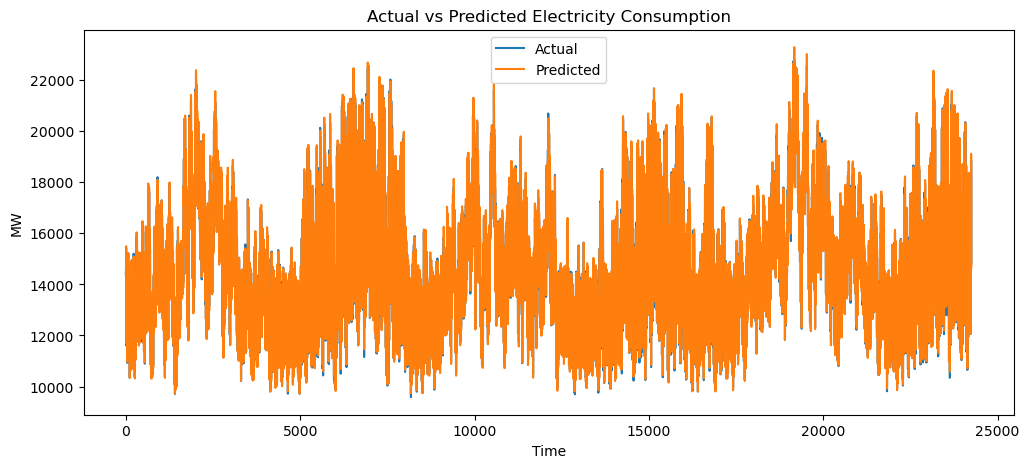

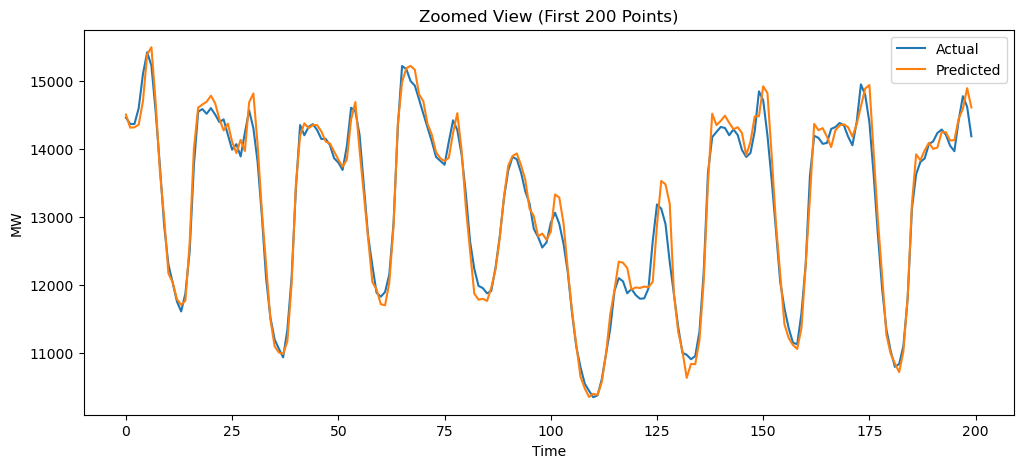

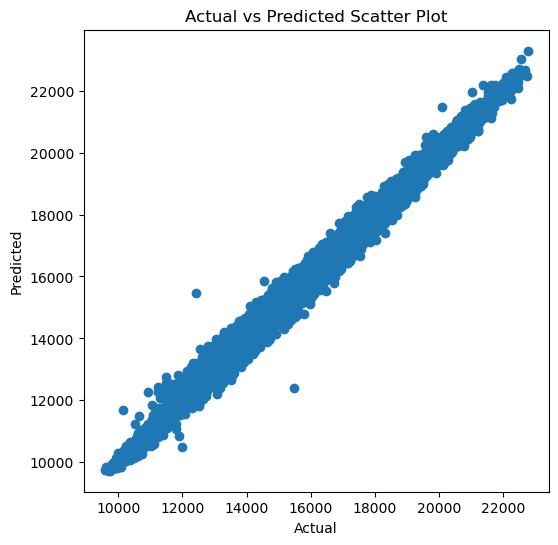

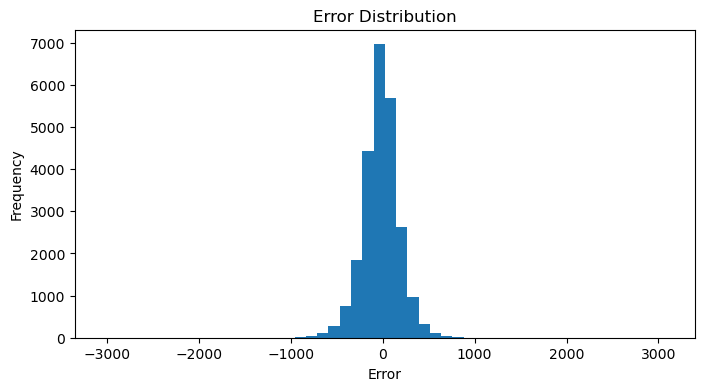

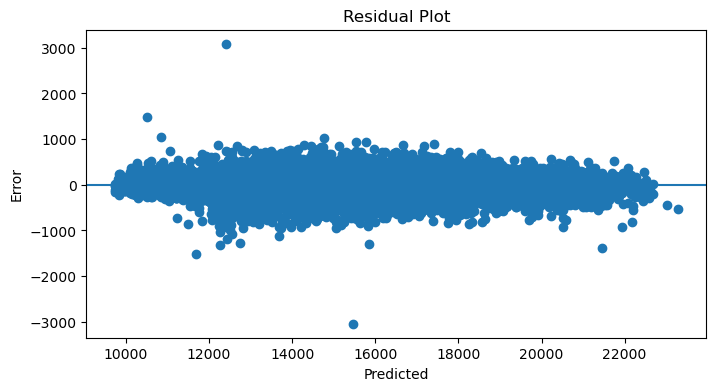

In [21]:
import matplotlib.pyplot as plt

# 1. Actual vs Predicted Line Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()


# 2. Zoomed Plot (First 200 values)
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Zoomed View (First 200 Points)")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()


# 3. Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()


# 4. Error Distribution
errors = y_test - y_pred

plt.figure(figsize=(8,4))
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


# 5. Residual Plot
plt.figure(figsize=(8,4))
plt.scatter(y_pred, errors)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.title("Residual Plot")
plt.show()